### GROUP MEMBERS : 
## 1. DAYANG FARAH FARZANA BINTI ABANG IDHAM (A23CS0071)
## 2. FARRA NURZAHIN BINTI ZAHARIL ANUAR (A23CS0079)
## 3. SAFIYA NURSYAHADAH BINTI MASNOOR (A23CS0176)

# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [16]:
# Import libraries
import pandas as pd
import numpy as np

# 1
df = pd.read_csv("Rainfall.csv", quotechar='"')
rainfall_df = df.iloc[:, 0].str.split(',', expand=True)
rainfall_df.columns = ['Region', 'Year', 'Month', 'Station', 
                       'Rainfall_mm', 'RainyDays', 'MaxTemp_C', 
                       'MinTemp_C', 'UrbanRural']
# 2
print("First 5 rows of the dataset:")
print(rainfall_df.head())

# 3
print("\nMissing values per column:")
print(rainfall_df.isnull().sum())

# 4
print("\nStatistical summary of numeric columns:")
numeric_cols = ['Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C']
rainfall_df[numeric_cols] = rainfall_df[numeric_cols].apply(pd.to_numeric, errors='coerce')
print(rainfall_df.describe())


First 5 rows of the dataset:
  Region  Year Month   Station Rainfall_mm RainyDays MaxTemp_C MinTemp_C  \
0  North  2023   Jan  StationA        56.2         9      12.1       2.5   
1  North  2023   Feb  StationA        72.1        12      14.7       3.0   
2  North  2023   Jan  StationB        60.5        10      11.2       1.8   
3  South  2023   Jan  StationC        81.0        13      19.6       7.2   
4  South  2023   Feb  StationC        63.4        11      20.1       7.7   

  UrbanRural  
0      Urban  
1      Urban  
2      Rural  
3      Urban  
4      Urban  

Missing values per column:
Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64

Statistical summary of numeric columns:
       Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C
count    10.000000   10.00000  10.000000  10.000000
mean     66.160000   10.90000  16.100000   4.740000
std      12.154121    1.66333   2

## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [18]:
#Write your code here

import pandas as pd

df_raw = pd.read_csv('Rainfall.csv', header=None)
df_split = df_raw[0].str.split(',', expand=True)
df_split.columns = df_split.iloc[0]
df = df_split.drop(index=0).reset_index(drop=True)

df.columns = df.columns.str.strip()

numeric_cols = ['Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean(numeric_only=True))
df['Station'] = df['Station'].fillna(df['Station'].mode()[0])

total_rainfall = df['Rainfall_mm'].groupby(df['Station']).sum()
avg_rainydays = df['RainyDays'].groupby(df['Station']).mean()
avg_maxtemp = df['MaxTemp_C'].groupby(df['Station']).mean()
avg_mintemp = df['MinTemp_C'].groupby(df['Station']).mean()

station_summary = pd.DataFrame({
    'Total_Rainfall_mm': total_rainfall,
    'Avg_RainyDays': avg_rainydays,
    'Avg_MaxTemp_C': avg_maxtemp,
    'Avg_MinTemp_C': avg_mintemp
})

print(station_summary)


          Total_Rainfall_mm  Avg_RainyDays  Avg_MaxTemp_C  Avg_MinTemp_C
Station                                                                 
StationA              128.3           10.5          13.40           2.75
StationB              122.0           10.5          13.10           2.50
StationC              144.4           12.0          19.85           7.45
StationD              105.3            9.0          16.65           5.90
StationE              161.6           12.5          17.50           5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [20]:
#Write your code here

avg_rainfall = df['Rainfall_mm'].groupby([df['Region'], df['UrbanRural']]).mean()

avg_maxtemp = df['MaxTemp_C'].groupby([df['Region'], df['UrbanRural']]).mean()

avg_rainydays = df['RainyDays'].groupby([df['Region'], df['UrbanRural']]).mean()

region_urban_summary = pd.DataFrame({
    'Avg_Rainfall_mm': avg_rainfall,
    'Avg_MaxTemp_C': avg_maxtemp,
    'Avg_RainyDays': avg_rainydays
})

print(region_urban_summary)



                   Avg_Rainfall_mm  Avg_MaxTemp_C  Avg_RainyDays
Region UrbanRural                                               
East   Rural                 52.65          16.65            9.0
North  Rural                 61.00          13.10           10.5
       Urban                 64.15          13.40           10.5
South  Urban                 72.20          19.85           12.0
West   Urban                 80.80          17.50           12.5


3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [22]:
#Write your code here

total_rainfall = df['Rainfall_mm'].groupby([df['Month'], df['Region']]).sum()

mean_rainfall = df['Rainfall_mm'].groupby([df['Month'], df['Region']]).mean()

min_rainfall = df['Rainfall_mm'].groupby([df['Month'], df['Region']]).min()

max_rainfall = df['Rainfall_mm'].groupby([df['Month'], df['Region']]).max()

monthly_region_summary = pd.DataFrame({
    'Total_Rainfall_mm': total_rainfall,
    'Mean_Rainfall_mm': mean_rainfall,
    'Min_Rainfall_mm': min_rainfall,
    'Max_Rainfall_mm': max_rainfall
})

print(monthly_region_summary)



              Total_Rainfall_mm  Mean_Rainfall_mm  Min_Rainfall_mm  \
Month Region                                                         
Feb   East                 59.6             59.60             59.6   
      North                72.1             72.10             72.1   
      South                63.4             63.40             63.4   
      West                 84.2             84.20             84.2   
Jan   East                 45.7             45.70             45.7   
      North               116.7             58.35             56.2   
      South                81.0             81.00             81.0   
      West                 77.4             77.40             77.4   
Mar   North                61.5             61.50             61.5   

              Max_Rainfall_mm  
Month Region                   
Feb   East               59.6  
      North              72.1  
      South              63.4  
      West               84.2  
Jan   East               45.7  
     

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [24]:
#Write your code here
max_rainfall_row = df[df['Rainfall_mm'] == df['Rainfall_mm'].max()]

print("Region and Month with the highest recorded rainfall:")
print(max_rainfall_row[['Region', 'Month', 'Rainfall_mm']])



Region and Month with the highest recorded rainfall:
0 Region Month  Rainfall_mm
8   West   Feb         84.2


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [26]:
#Write your code here

avg_rainfall = df['Rainfall_mm'].groupby([df['Year'], df['UrbanRural']]).mean()

min_rainfall = df['Rainfall_mm'].groupby([df['Year'], df['UrbanRural']]).min()

max_rainfall = df['Rainfall_mm'].groupby([df['Year'], df['UrbanRural']]).max()

year_urban_summary = pd.DataFrame({
    'Avg_Rainfall_mm': avg_rainfall,
    'Min_Rainfall_mm': min_rainfall,
    'Max_Rainfall_mm': max_rainfall
})

print("Average, Min, and Max Rainfall by Year and Urban/Rural:")
print(year_urban_summary)


Average, Min, and Max Rainfall by Year and Urban/Rural:
                 Avg_Rainfall_mm  Min_Rainfall_mm  Max_Rainfall_mm
Year UrbanRural                                                   
2023 Rural             56.825000             45.7             61.5
     Urban             72.383333             56.2             84.2


6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [28]:
#Write your code here

df['TempRange'] = df['MaxTemp_C'] - df['MinTemp_C']

avg_temp_range = df['TempRange'].groupby([df['Region'], df['Month']]).mean()

print("Average Temperature Range per Month for Each Region:")
print(avg_temp_range)


Average Temperature Range per Month for Each Region:
Region  Month
East    Feb      11.7
        Jan       9.8
North   Feb      11.7
        Jan       9.5
        Mar      11.8
South   Feb      12.4
        Jan      12.4
West    Feb      12.9
        Jan      11.9
Name: TempRange, dtype: float64


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



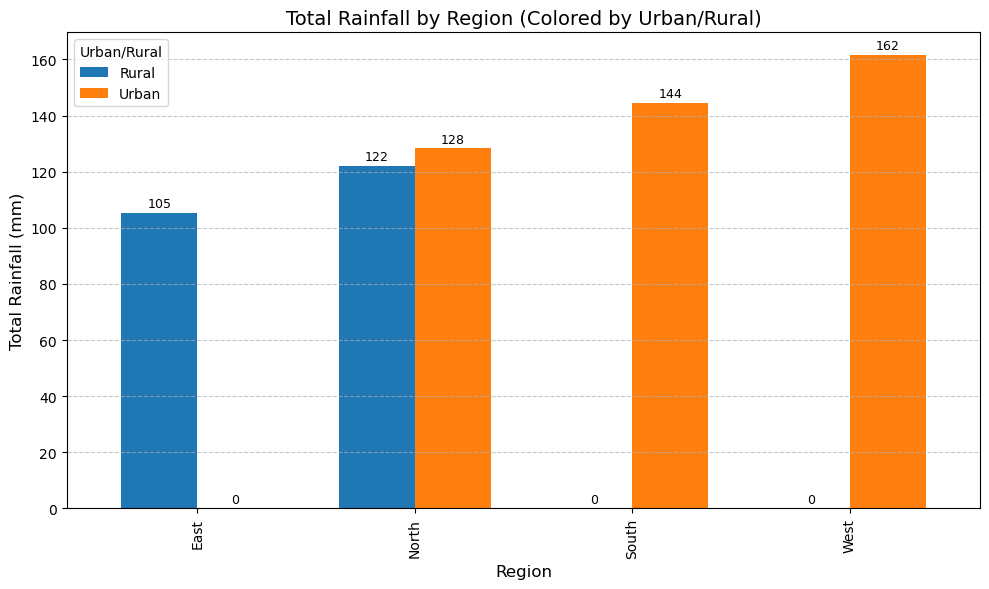

In [30]:
#Write your code here
import pandas as pd
import matplotlib.pyplot as plt

total_rainfallbyRegion = df.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum().reset_index()

pivot_df = total_rainfallbyRegion.pivot(index='Region', columns='UrbanRural', values='Rainfall_mm')

ax = pivot_df.plot.bar(figsize=(10,6), width=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9, padding=2)

plt.title('Total Rainfall by Region (Colored by Urban/Rural)', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Rainfall (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Urban/Rural')

plt.tight_layout()

plt.show()


2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



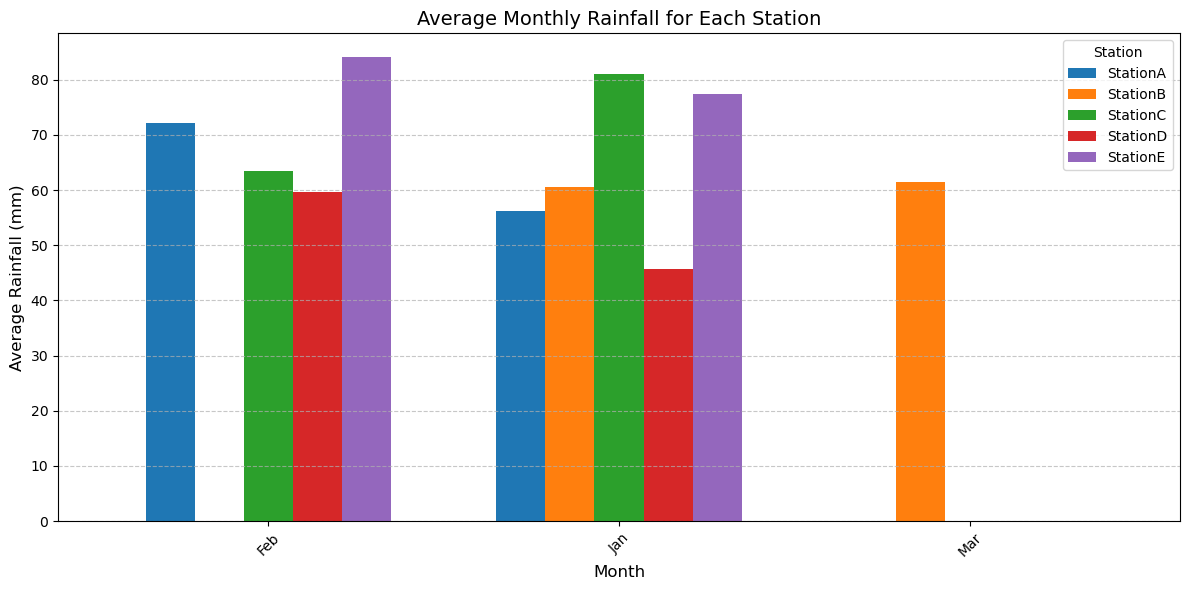

In [32]:
#Write your code here

avg_rainfallbyStation = df.groupby(['Month', 'Station'])['Rainfall_mm'].mean().reset_index()

pivot_avg = avg_rainfallbyStation.pivot(index='Month', columns='Station', values='Rainfall_mm')

ax = pivot_avg.plot.bar(figsize=(12,6), width=0.7)

plt.title('Average Monthly Rainfall for Each Station', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Station')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



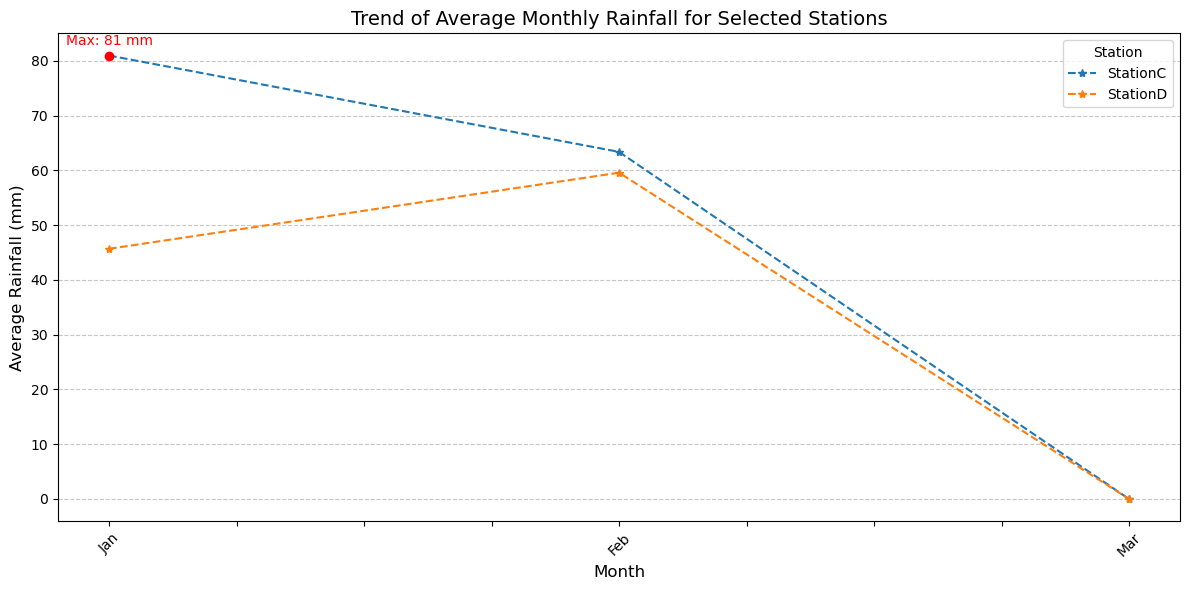

In [34]:
#Write your code here

selected_stations = ['StationC', 'StationD']

filtered_df = df[df['Station'].isin(selected_stations)]

avg_monthly = filtered_df.groupby(['Month', 'Station'])['Rainfall_mm'].mean().reset_index()

pivot_line = avg_monthly.pivot(index='Month', columns='Station', values='Rainfall_mm')

month_order = ['Jan', 'Feb', 'Mar']
pivot_line = pivot_line.reindex(month_order)
pivot_line = pivot_line.fillna(0)

ax = pivot_line.plot(
    kind='line',
    marker='*',              
    linestyle='--',          
    figsize=(12,6)
)

max_month = pivot_line.max(axis=1).idxmax()   
max_value = pivot_line.max(axis=1).max()    

for station in pivot_line.columns:
    if pivot_line.loc[max_month, station] == max_value:
        ax.plot(max_month, max_value, 'ro')
        ax.text(max_month, max_value+2, f'Max: {max_value:.0f} mm', color='red', fontsize=10, ha='center')

plt.title('Trend of Average Monthly Rainfall for Selected Stations', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Station')
plt.tight_layout()

plt.show()


4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



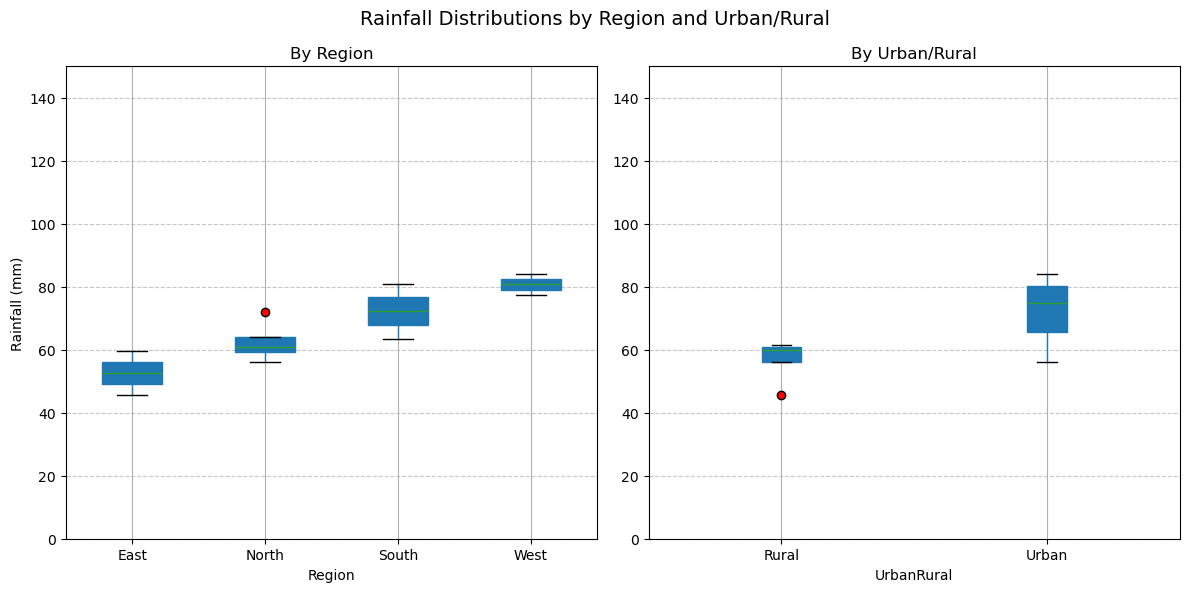

In [36]:
#Write your code here

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

bp1 = df.boxplot(
    column='Rainfall_mm',
    by='Region',
    ax=axes[0],
    patch_artist=True
)

colors1 = ['skyblue', 'lightgreen', 'lightpink', 'khaki', 'lightgray']
for patch, color in zip(bp1.artists, colors1):
    patch.set_facecolor(color)

for line in bp1.lines:
    line.set_markerfacecolor('red')
    line.set_markersize(6)

axes[0].set_title('By Region')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].set_ylim(0, 150)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

bp2=df.boxplot(
    column='Rainfall_mm',
    by='UrbanRural',
    ax=axes[1],
    patch_artist=True
)

colors2 = ['lightblue', 'lightgreen']
for patch, color in zip(bp2.artists, colors2):
    patch.set_facecolor(color)

for line in bp2.lines:
    line.set_markerfacecolor('red')
    line.set_markersize(6)

axes[1].set_title('By Urban/Rural')
axes[1].set_ylim(0, 150)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Rainfall Distributions by Region and Urban/Rural', fontsize=14)

plt.tight_layout()

plt.show()


5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



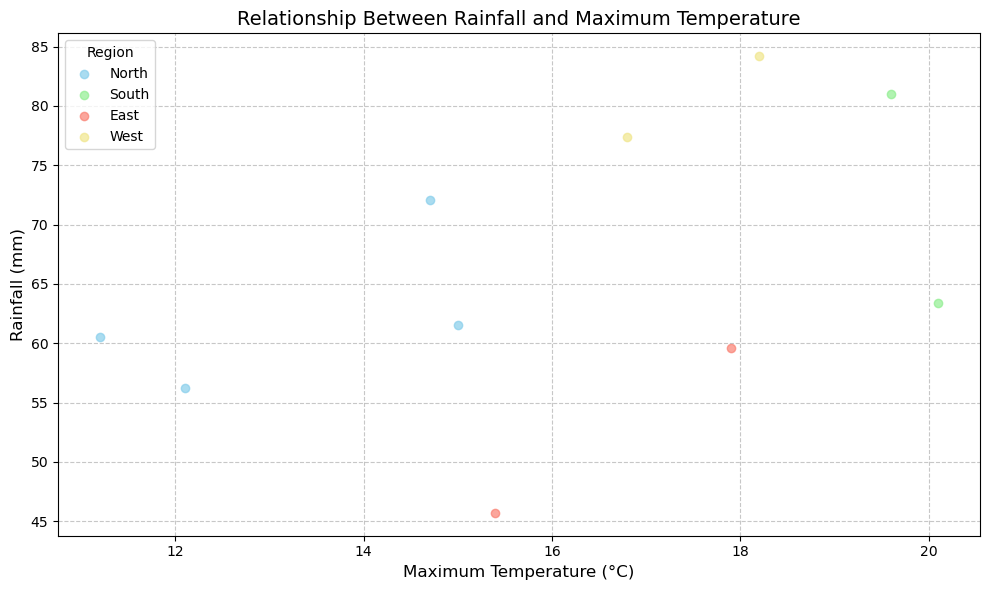

In [38]:
#Write your code here

regions = df['Region'].unique()
colors = ['skyblue', 'lightgreen', 'salmon', 'khaki', 'plum']
color_map = dict(zip(regions, colors))
plt.figure(figsize=(10,6))

for region in regions:
    sub_df = df[df['Region'] == region]
    plt.scatter(
        sub_df['MaxTemp_C'],
        sub_df['Rainfall_mm'],
        label=region,
        color=color_map[region],
        alpha=0.7
    )

plt.title('Relationship Between Rainfall and Maximum Temperature', fontsize=14)
plt.xlabel('Maximum Temperature (°C)', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.legend(title='Region')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



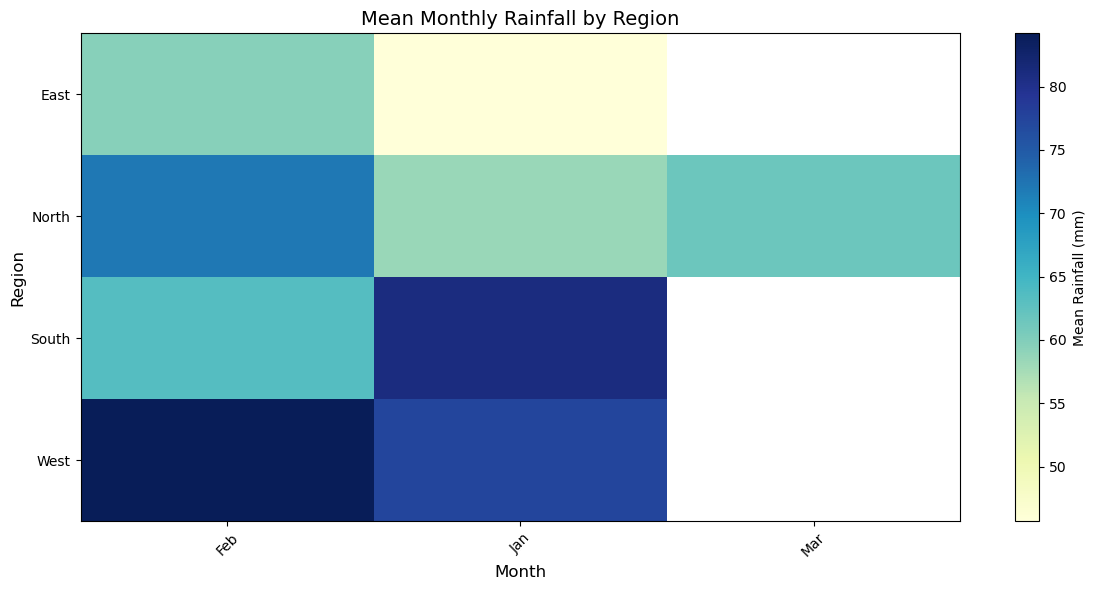

In [40]:
#Write your code here

mean_rainfall = df.groupby(['Region', 'Month'])['Rainfall_mm'].mean().reset_index()

heatmap_data = mean_rainfall.pivot(index='Region', columns='Month', values='Rainfall_mm')

plt.figure(figsize=(12,6))
plt.imshow(heatmap_data, cmap='YlGnBu', aspect='auto')

plt.colorbar(label='Mean Rainfall (mm)')
plt.title('Mean Monthly Rainfall by Region', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Region', fontsize=12)

plt.xticks(ticks=range(len(heatmap_data.columns)), labels=heatmap_data.columns, rotation=45)
plt.yticks(ticks=range(len(heatmap_data.index)), labels=heatmap_data.index)

plt.tight_layout()

plt.show()


7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

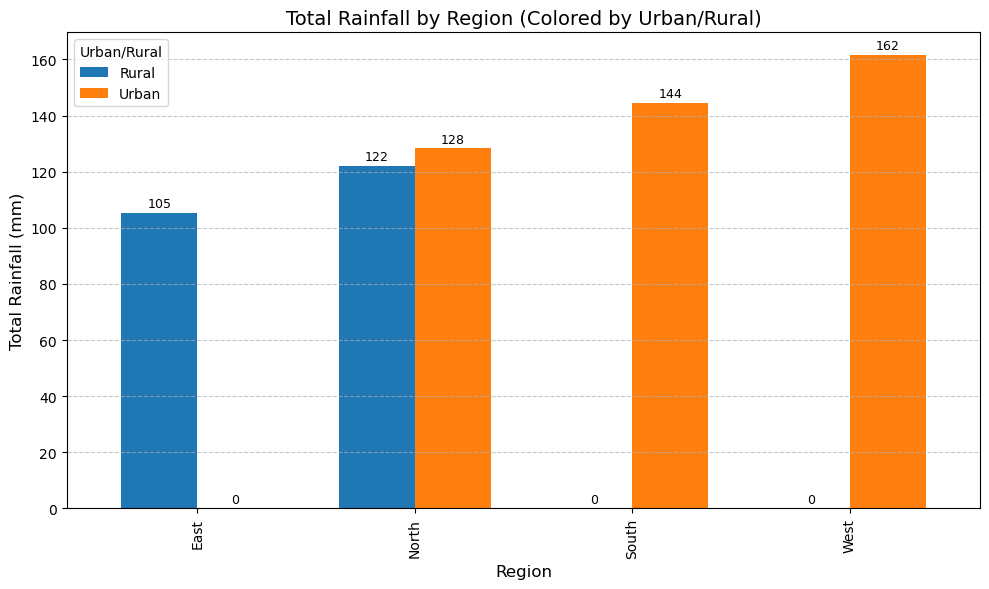

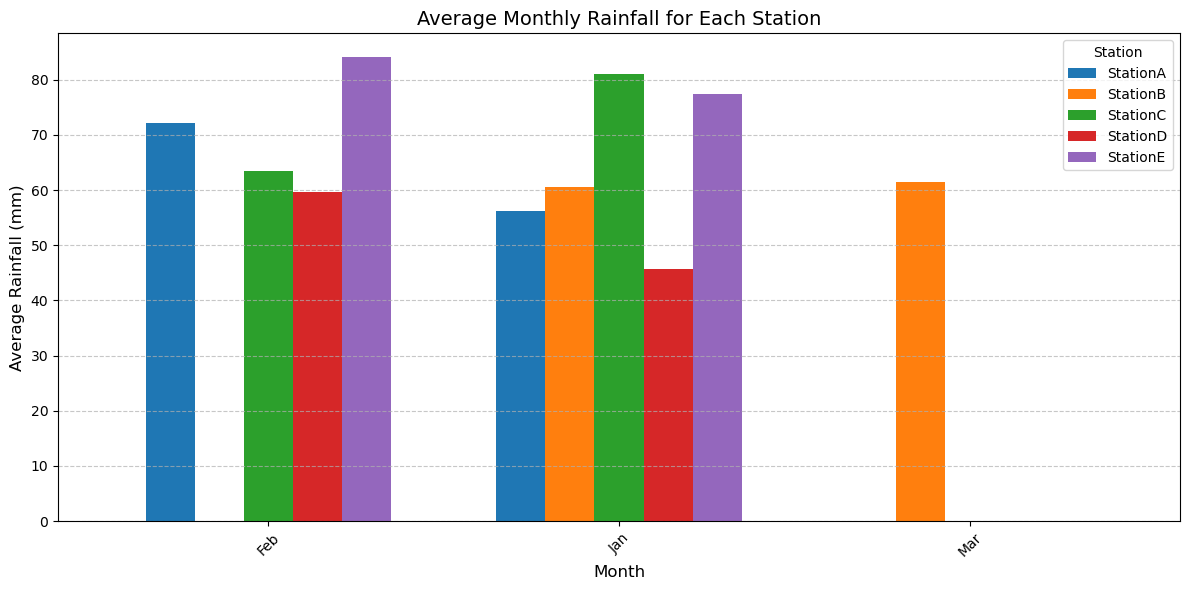

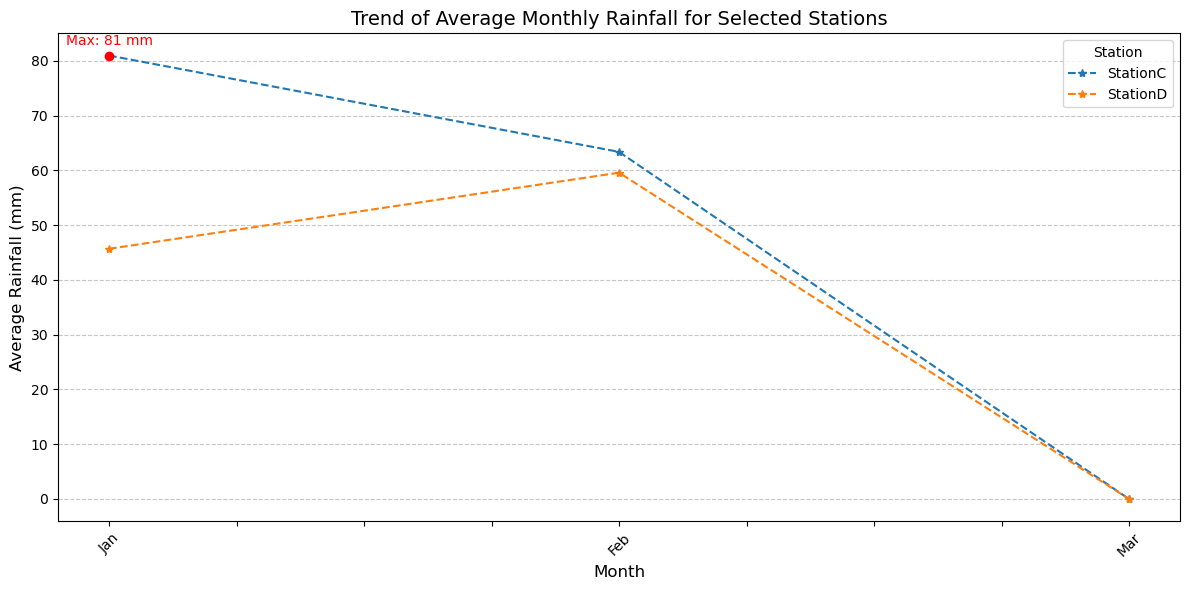

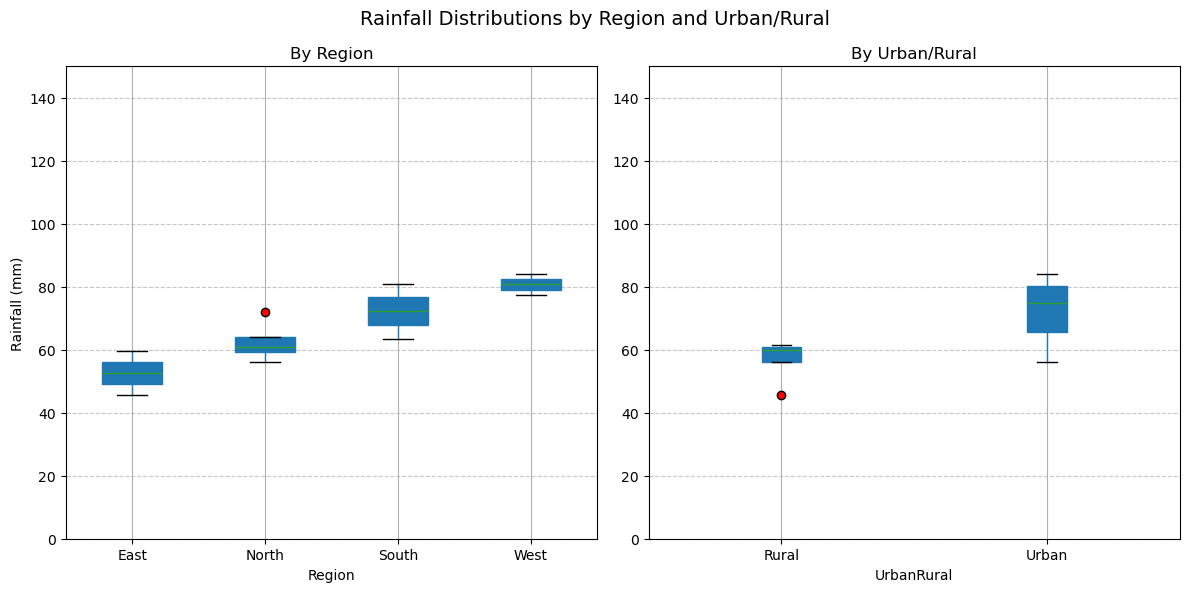

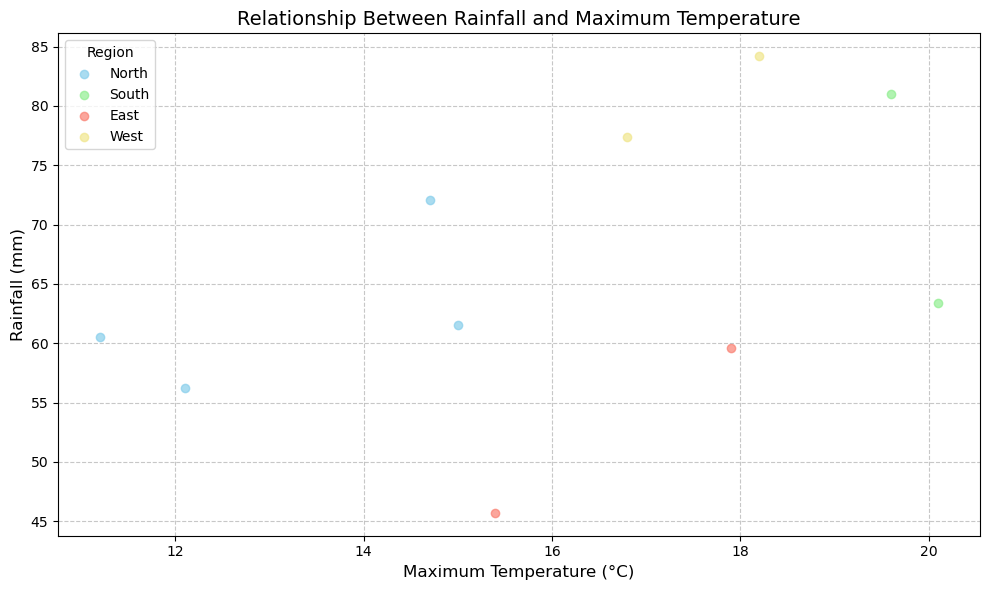

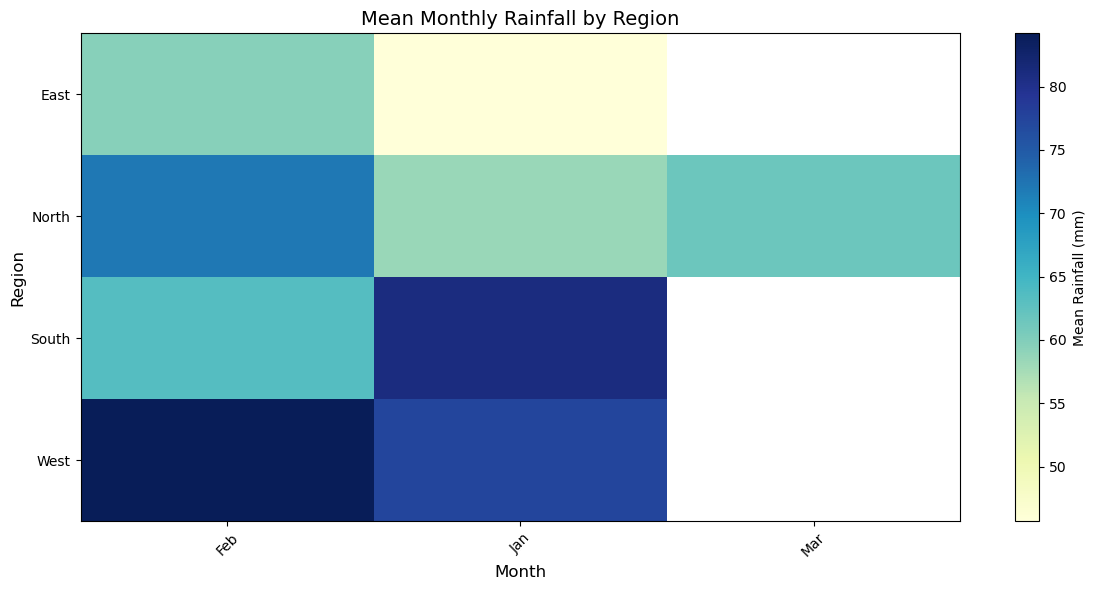

In [42]:
#Write your code here

#Bar Chart
ax = pivot_df.plot.bar(figsize=(10,6), width=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9, padding=2)

plt.title('Total Rainfall by Region (Colored by Urban/Rural)', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Rainfall (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Urban/Rural')

plt.tight_layout()

plt.savefig('total_rainfall_by_region.png', dpi=300)
plt.show()

#Grouped bar chart

ax = pivot_avg.plot.bar(figsize=(12,6), width=0.7)

plt.title('Average Monthly Rainfall for Each Station', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Station')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig('average_monthly_rainfall_stations.png', dpi=300)
plt.show()

#Line plot

ax = pivot_line.plot(
    kind='line',
    marker='*',              
    linestyle='--',          
    figsize=(12,6)
)

max_month = pivot_line.max(axis=1).idxmax()   
max_value = pivot_line.max(axis=1).max()    

for station in pivot_line.columns:
    if pivot_line.loc[max_month, station] == max_value:
        ax.plot(max_month, max_value, 'ro')
        ax.text(max_month, max_value+2, f'Max: {max_value:.0f} mm', color='red', fontsize=10, ha='center')

plt.title('Trend of Average Monthly Rainfall for Selected Stations', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Station')
plt.tight_layout()

plt.savefig('trend_monthly_rainfall_selected_stations.png', dpi=300)
plt.show()

#Box plot

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

bp1 = df.boxplot(
    column='Rainfall_mm',
    by='Region',
    ax=axes[0],
    patch_artist=True
)

colors1 = ['skyblue', 'lightgreen', 'lightpink', 'khaki', 'lightgray']
for patch, color in zip(bp1.artists, colors1):
    patch.set_facecolor(color)

for line in bp1.lines:
    line.set_markerfacecolor('red')
    line.set_markersize(6)

axes[0].set_title('By Region')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].set_ylim(0, 150)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

bp2=df.boxplot(
    column='Rainfall_mm',
    by='UrbanRural',
    ax=axes[1],
    patch_artist=True
)

colors2 = ['lightblue', 'lightgreen']
for patch, color in zip(bp2.artists, colors2):
    patch.set_facecolor(color)

for line in bp2.lines:
    line.set_markerfacecolor('red')
    line.set_markersize(6)

axes[1].set_title('By Urban/Rural')
axes[1].set_ylim(0, 150)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Rainfall Distributions by Region and Urban/Rural', fontsize=14)

plt.tight_layout()
plt.savefig('boxplot_rainfall_distribution.png', dpi=300)
plt.show()

#Scatter plot

plt.figure(figsize=(10,6))

for region in regions:
    sub_df = df[df['Region'] == region]
    plt.scatter(
        sub_df['MaxTemp_C'],
        sub_df['Rainfall_mm'],
        label=region,
        color=color_map[region],
        alpha=0.7
    )

plt.title('Relationship Between Rainfall and Maximum Temperature', fontsize=14)
plt.xlabel('Maximum Temperature (°C)', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.legend(title='Region')
plt.grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig('scatterplot_rainfall_vs_maxtemp.png', dpi=300)
plt.show()

#Heatmap

plt.figure(figsize=(12,6))
plt.imshow(heatmap_data, cmap='YlGnBu', aspect='auto')

plt.colorbar(label='Mean Rainfall (mm)')
plt.title('Mean Monthly Rainfall by Region', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Region', fontsize=12)

plt.xticks(ticks=range(len(heatmap_data.columns)), labels=heatmap_data.columns, rotation=45)
plt.yticks(ticks=range(len(heatmap_data.index)), labels=heatmap_data.index)

plt.tight_layout()

plt.savefig('heatmap_mean_monthly_rainfall.png', dpi=300)
plt.show()


## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


C:\Users\safiy\AppData\Local\Temp\ipykernel_10076\1461773573.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_rainfall = df.groupby('Month')['Rainfall_mm'].mean().dropna().reset_index()


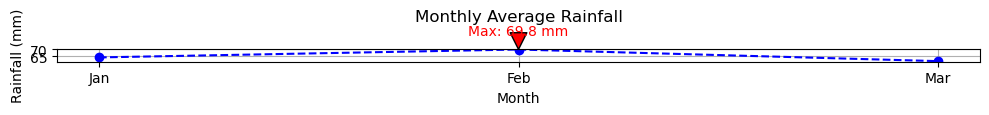

In [66]:
import matplotlib.pyplot as plt

monthly_rainfall = df.groupby('Month')['Rainfall_mm'].mean().dropna().reset_index()

month_labels = monthly_rainfall['Month'].tolist()
y_values = monthly_rainfall['Rainfall_mm'].tolist()
x_values = list(range(len(month_labels)))

max_index = y_values.index(max(y_values))
max_month = month_labels[max_index]
max_value = y_values[max_index]

min_index = y_values.index(min(y_values))
min_value = y_values[min_index]

plt.figure(figsize=(10, 5))
plt.plot(x_values, y_values, marker='o', linestyle='--', color='blue')
plt.xticks(ticks=x_values, labels=month_labels)
plt.title('Monthly Average Rainfall', pad=20)
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.grid(True)

plt.annotate(f'Max: {max_value:.1f} mm',
             xy=(max_index, max_value),
             xytext=(max_index, max_value + 10),
             ha='center',
            color='red',
             arrowprops=dict(facecolor='red', shrink=0.01))

plt.tight_layout()
plt.show()

2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


C:\Users\safiy\AppData\Local\Temp\ipykernel_10076\4179975026.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = df.groupby(['Region', 'UrbanRural', 'Month'])['Rainfall_mm'].mean().reset_index()


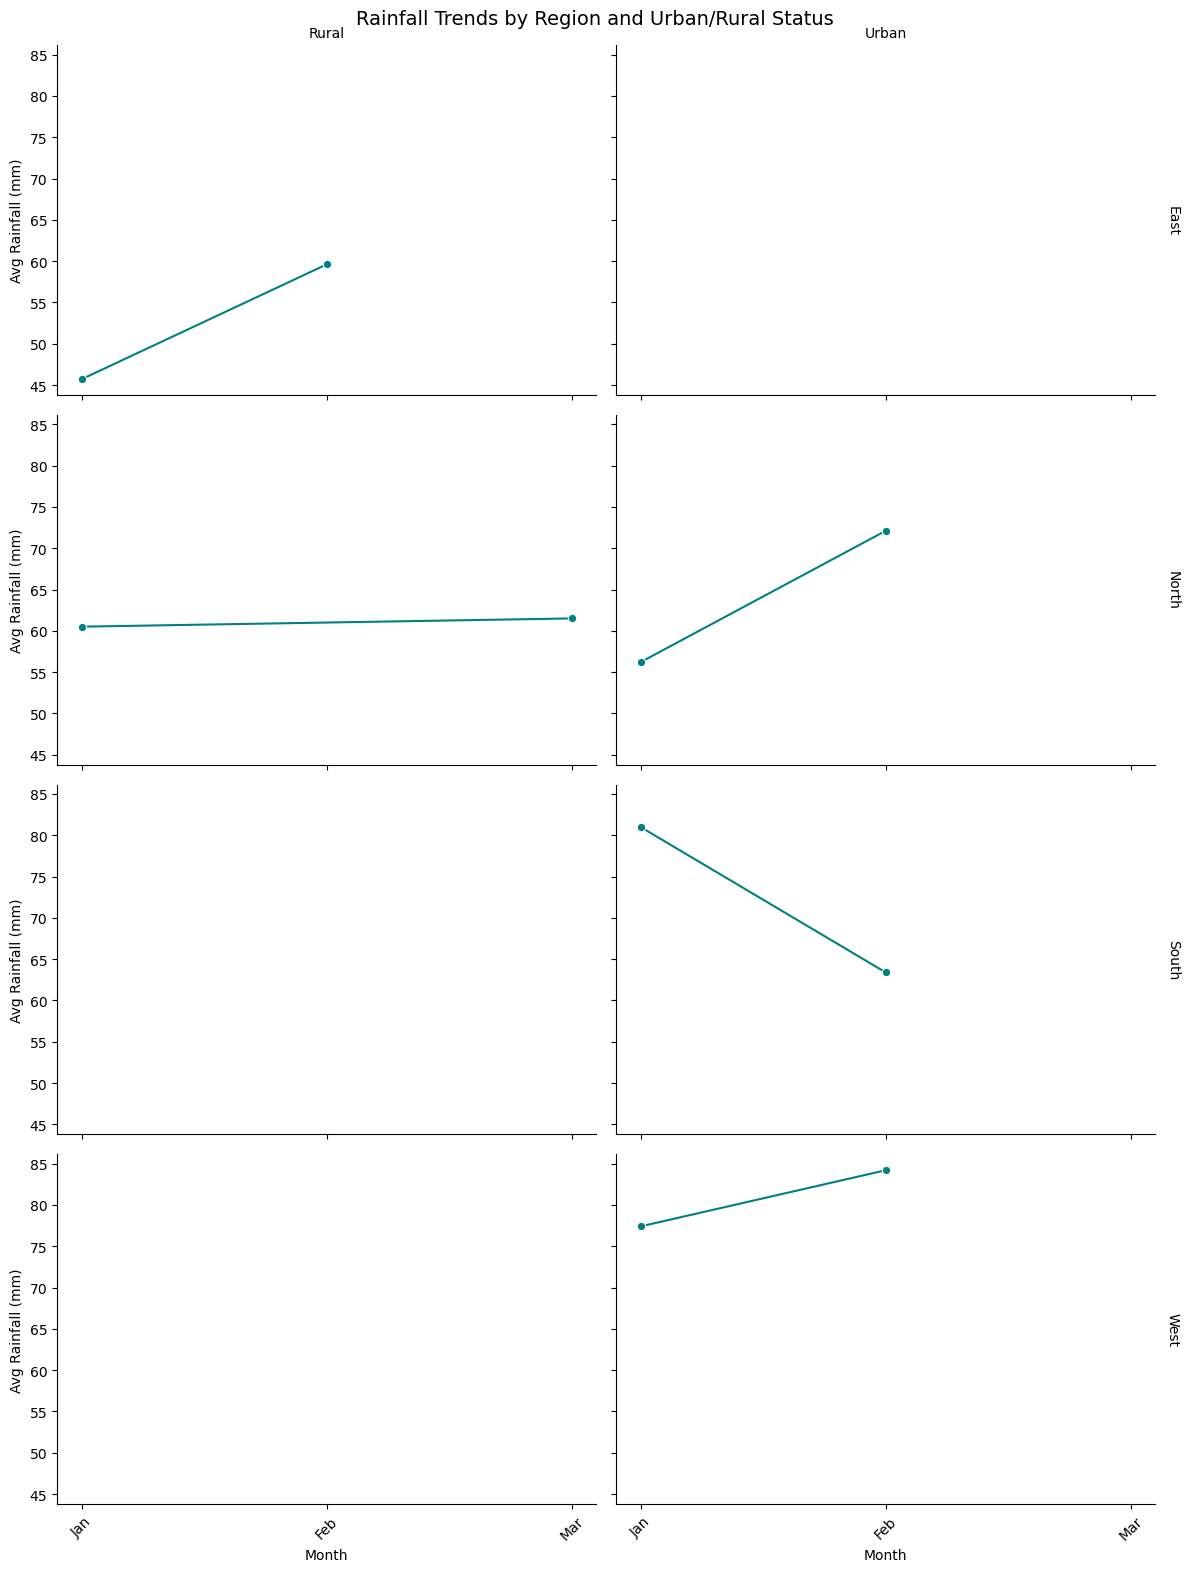

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

grouped_df = df.groupby(['Region', 'UrbanRural', 'Month'])['Rainfall_mm'].mean().reset_index()

g = sns.FacetGrid(grouped_df, row='Region', col='UrbanRural', height=4, aspect=1.5, margin_titles=True)

g.map_dataframe(sns.lineplot, x='Month', y='Rainfall_mm', marker='o', color='teal')

g.set_axis_labels("Month", "Avg Rainfall (mm)")
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Rainfall Trends by Region and Urban/Rural Status', fontsize=14)

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here

- The highest average monthly rainfall was recorded in **February**, with a value of 69.8mm.
- From the annotated line plot, we can observe a relatively consistent rainfall pattern from january to March with a peak in February.
- The facet grid clearly shows how rainfall trends differ by both region and Urban/Rural classification. 
For example, in the North region, urban areas experiences more rainfall than rural ones in February. The South region displayed the opposite trend urban rainfall dropped while rural rainfall increased.
-These patterns suggest that regional and environmental factors may influence local rainfall variations.